In [41]:
import json
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
import psutil
import shap
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score,
    confusion_matrix, precision_recall_curve,
    roc_auc_score, roc_curve, f1_score,
)

from train_xgb import FEATURE_COLS

MODELS_DIR = "data/models"
TEST_PARQUET = "data/test.parquet"
FIGURES_DIR = "data/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.rcParams.update({"figure.dpi": 150, "font.size": 11})

In [ ]:
df_test = pd.read_parquet(TEST_PARQUET)
df_test["y"] = (df_test["label"] != "benign").astype(int)
df_test = df_test.dropna(subset=FEATURE_COLS)

X_test = df_test[FEATURE_COLS].values.astype(np.float32)
y_test  = df_test["y"].values
print(f"Test set: {len(X_test)} events, {y_test.mean()*100:.1f}% anomaly")

Test set: 2614 events, 34.0% anomaly


In [ ]:
def onnx_predict_proba(model_path: str, X: np.ndarray) -> np.ndarray:
    sess = ort.InferenceSession(model_path)
    input_name = sess.get_inputs()[0].name
    out = sess.run(None, {input_name: X.astype(np.float32)})
    probs = out[1]
    # XGBoost ONNX: tensor(float) shape (N, 2)
    # LightGBM ONNX: seq(map(int64, tensor(float))) → list of dicts
    if isinstance(probs, list):
        return np.array([d[1] for d in probs])
    return probs[:, 1]

xgb_proba  = onnx_predict_proba(f"{MODELS_DIR}/model_xgb.onnx",  X_test)
lgbm_proba = onnx_predict_proba(f"{MODELS_DIR}/model_lgbm.onnx", X_test)

for name, proba in [("XGBoost", xgb_proba), ("LightGBM", lgbm_proba)]:
    roc  = roc_auc_score(y_test, proba)
    pr   = average_precision_score(y_test, proba)
    f1   = f1_score(y_test, (proba >= 0.5).astype(int))
    print(f"{name}: ROC-AUC={roc:.4f}  PR-AUC={pr:.4f}  F1@0.5={f1:.4f}")

XGBoost: ROC-AUC=0.9992  PR-AUC=0.9985  F1@0.5=0.9770
LightGBM: ROC-AUC=0.9992  PR-AUC=0.9986  F1@0.5=0.9677


2026-05-20 07:51:41.174084477 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {1} does not match actual shape of {2614} for output label


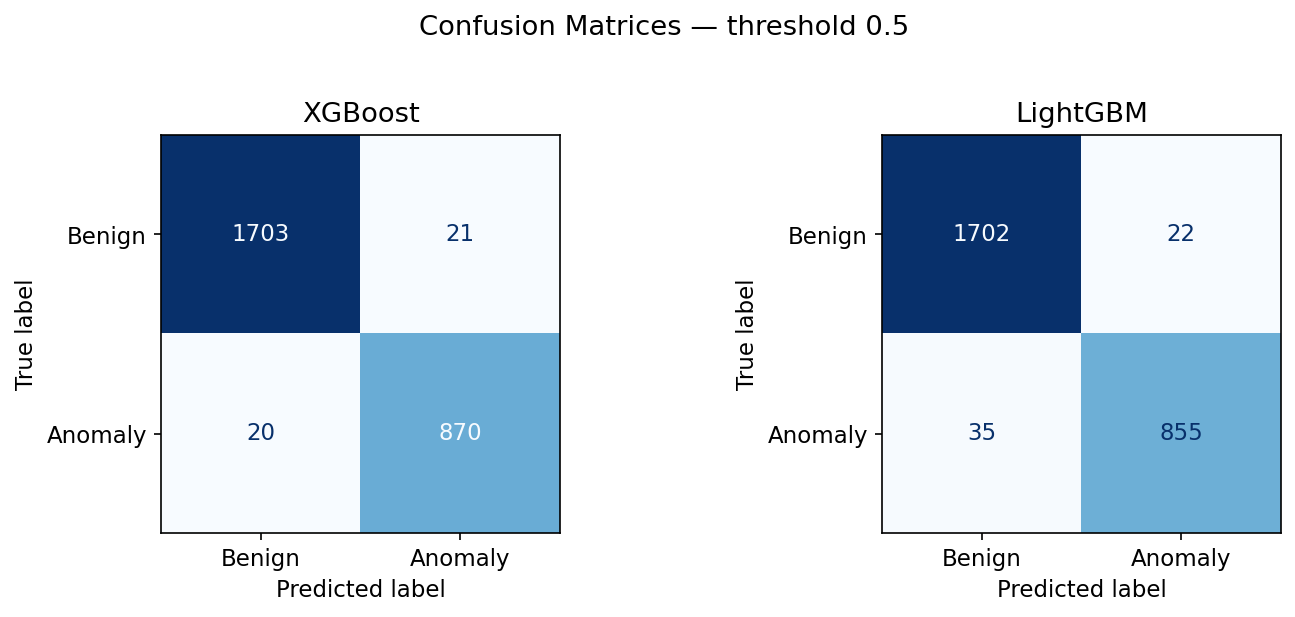

Saved confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, proba, name in zip(axes,
                            [xgb_proba, lgbm_proba],
                            ["XGBoost", "LightGBM"]):
    cm = confusion_matrix(y_test, (proba >= 0.5).astype(int))
    disp = ConfusionMatrixDisplay(cm, display_labels=["Benign", "Anomaly"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.suptitle("Confusion Matrices - threshold 0.5", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/confusion_matrices.png", bbox_inches="tight")
plt.show()
print("Saved confusion_matrices.png")

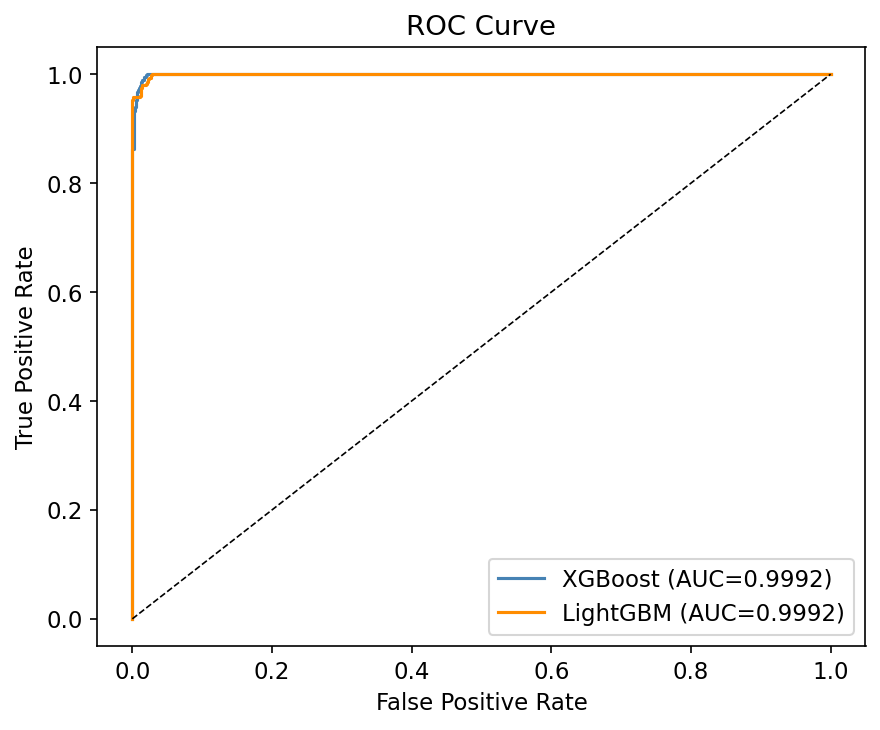

Saved roc_curve.png


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
for proba, name, color in [(xgb_proba,  "XGBoost",  "steelblue"),
                            (lgbm_proba, "LightGBM", "darkorange")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})", color=color)
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/roc_curve.png", bbox_inches="tight")
plt.show()
print("Saved roc_curve.png")

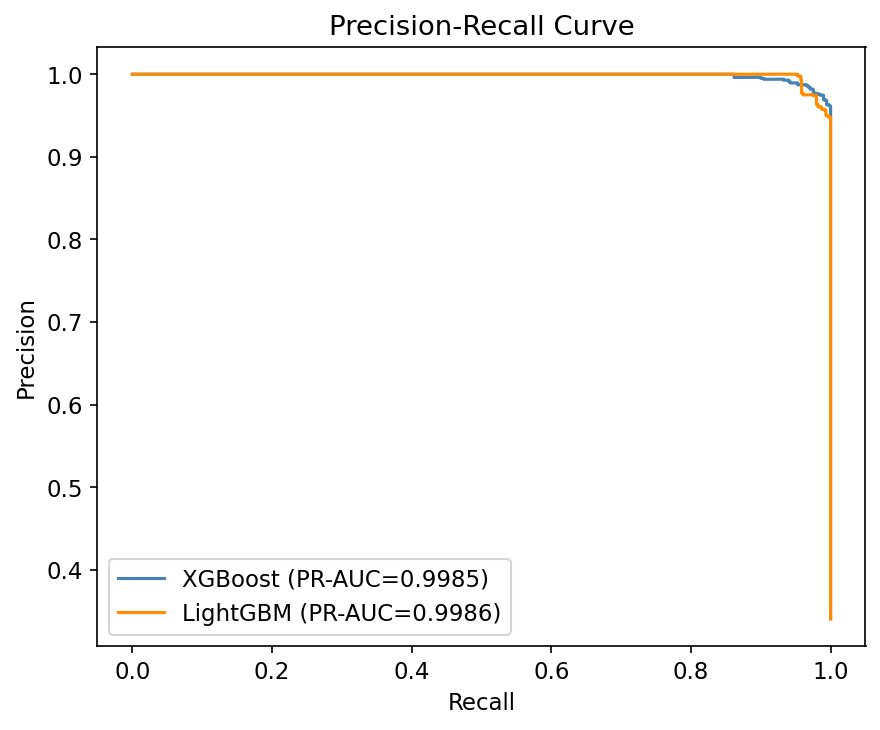

Saved pr_curve.png


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
for proba, name, color in [(xgb_proba,  "XGBoost",  "steelblue"),
                            (lgbm_proba, "LightGBM", "darkorange")]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    ax.plot(rec, prec, label=f"{name} (PR-AUC={pr_auc:.4f})", color=color)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/pr_curve.png", bbox_inches="tight")
plt.show()
print("Saved pr_curve.png")

In [ ]:
# Load native models for SHAP (TreeExplainer requires original booster, not ONNX)
xgb_native = xgb.XGBClassifier()
xgb_native.load_model(f"{MODELS_DIR}/xgb_model.json")
lgbm_native = lgb.Booster(model_file=f"{MODELS_DIR}/lgbm_model.txt")

df_train = pd.read_parquet("data/train.parquet").dropna(subset=FEATURE_COLS)
X_shap = df_train[FEATURE_COLS].values.astype(np.float32)[:2000]

FEATURE_LABELS = [
    "country_hash (country of request)",
    "asn (network provider / ASN)",
    "endpoint_hash (API endpoint)",
    "endpoint_lag1_hash (prev. endpoint, t-1)",
    "endpoint_lag2_hash (prev. endpoint, t-2)",
    "role_hash (current role)",
    "role_lag1_hash (prev. role, t-1)",
    "delta_ts_t1_s (time since last request, s)",
    "is_high_privilege_role (high-privilege role flag)",
    "session_age_s (session age, s)",
    "session_total_actions (total actions in session)",
    "unique_endpoints (unique endpoints in session)",
    "req_count_1m (requests in last 1 min)",
    "failed_req_count_1m (failed requests in 1 min)",
    "req_count_5m (requests in last 5 min)",
    "reads_5m (read ops in 5 min)",
    "writes_5m (write ops in 5 min)",
    "read_write_ratio_5m (read/write ratio, 5 min)",
    "interarrival_avg_5m (avg. inter-request gap, 5 min)",
    "req_count_15m (requests in last 15 min)",
    "role_mismatch_count_5m (role mismatches, 5 min)",
    "simultaneous_ip_count (concurrent IPs in session)",
    "mass_request_score (mass request anomaly score)",
    "unique_roles_requested_5m (unique roles requested, 5 min)",
    "hour_sin (hour of day, sin)",
    "hour_cos (hour of day, cos)",
    "is_weekend (weekend flag)",
    "is_outside_hours (outside business hours)",
]

for native_model, name, fname in [
    (xgb_native,  "XGBoost",  "shap_xgb.png"),
    (lgbm_native, "LightGBM", "shap_lgbm.png"),
]:
    explainer   = shap.TreeExplainer(native_model)
    shap_values = explainer.shap_values(X_shap)
    # LightGBM binary returns a list
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values
    plt.figure(figsize=(12, 7))
    shap.summary_plot(sv, X_shap, feature_names=FEATURE_LABELS,
                      plot_type="bar", show=False)
    plt.title(f"SHAP Feature Importance - {name}")
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{fname}", bbox_inches="tight")
    plt.close()
    print(f"Saved {fname}")

Saved shap_xgb.png


/home/mdvvvv/win_prog/bakis/ml/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Saved shap_lgbm.png


In [ ]:
def benchmark(model_path: str, X_sample: np.ndarray, n: int = 1000) -> dict:
    proc = psutil.Process()

    mem_before = proc.memory_info().rss
    sess = ort.InferenceSession(model_path)
    mem_after = proc.memory_info().rss
    input_name = sess.get_inputs()[0].name

    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        sess.run(None, {input_name: X_sample})
        times.append(time.perf_counter() - t0)
    times.sort()

    return {
        "p50_ms":  times[n // 2] * 1000,
        "p95_ms":  times[int(n * 0.95)] * 1000,
        "rss_mb":  (mem_after - mem_before) / 1e6,
        "size_mb": os.path.getsize(model_path) / 1e6,
    }

sample = X_test[:1]
bench_results = {
    "XGBoost":  benchmark(f"{MODELS_DIR}/model_xgb.onnx",  sample),
    "LightGBM": benchmark(f"{MODELS_DIR}/model_lgbm.onnx", sample),
}
for name, r in bench_results.items():
    print(f"{name}: p50={r['p50_ms']:.3f}ms  p95={r['p95_ms']:.3f}ms  "
          f"RAM={r['rss_mb']:.1f}MB  size={r['size_mb']:.2f}MB")

XGBoost: p50=0.017ms  p95=0.048ms  RAM=0.0MB  size=0.03MB
LightGBM: p50=0.022ms  p95=0.061ms  RAM=0.9MB  size=0.29MB


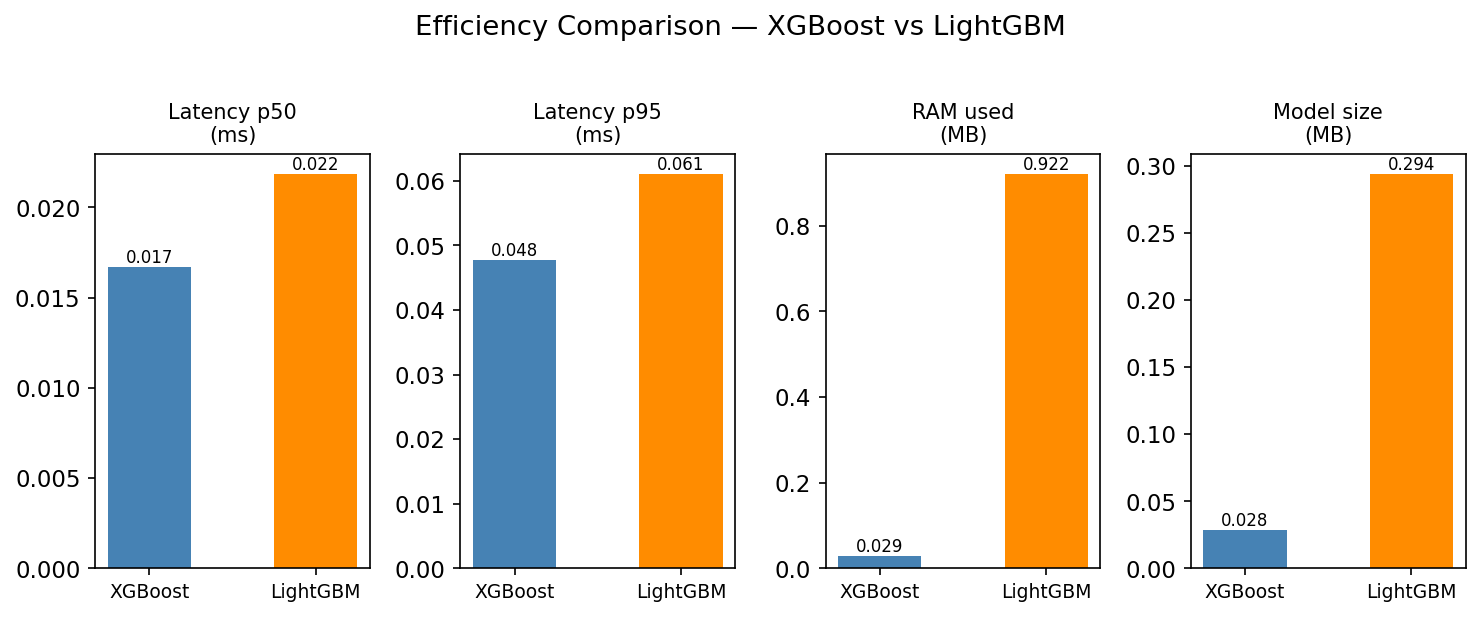

Saved efficiency_comparison.png


In [ ]:
metrics = ["p50_ms", "p95_ms", "rss_mb", "size_mb"]
labels  = ["Latency p50\n(ms)", "Latency p95\n(ms)", "RAM used\n(MB)", "Model size\n(MB)"]
model_names = list(bench_results.keys())
colors = ["steelblue", "darkorange"]

fig, axes = plt.subplots(1, len(metrics), figsize=(10, 4))
for ax, metric, label in zip(axes, metrics, labels):
    vals = [bench_results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors, width=0.5)
    ax.set_title(label, fontsize=10)
    ax.tick_params(axis="x", labelsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("Efficiency Comparison - XGBoost vs LightGBM", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/efficiency_comparison.png", bbox_inches="tight")
plt.show()
print("Saved efficiency_comparison.png")

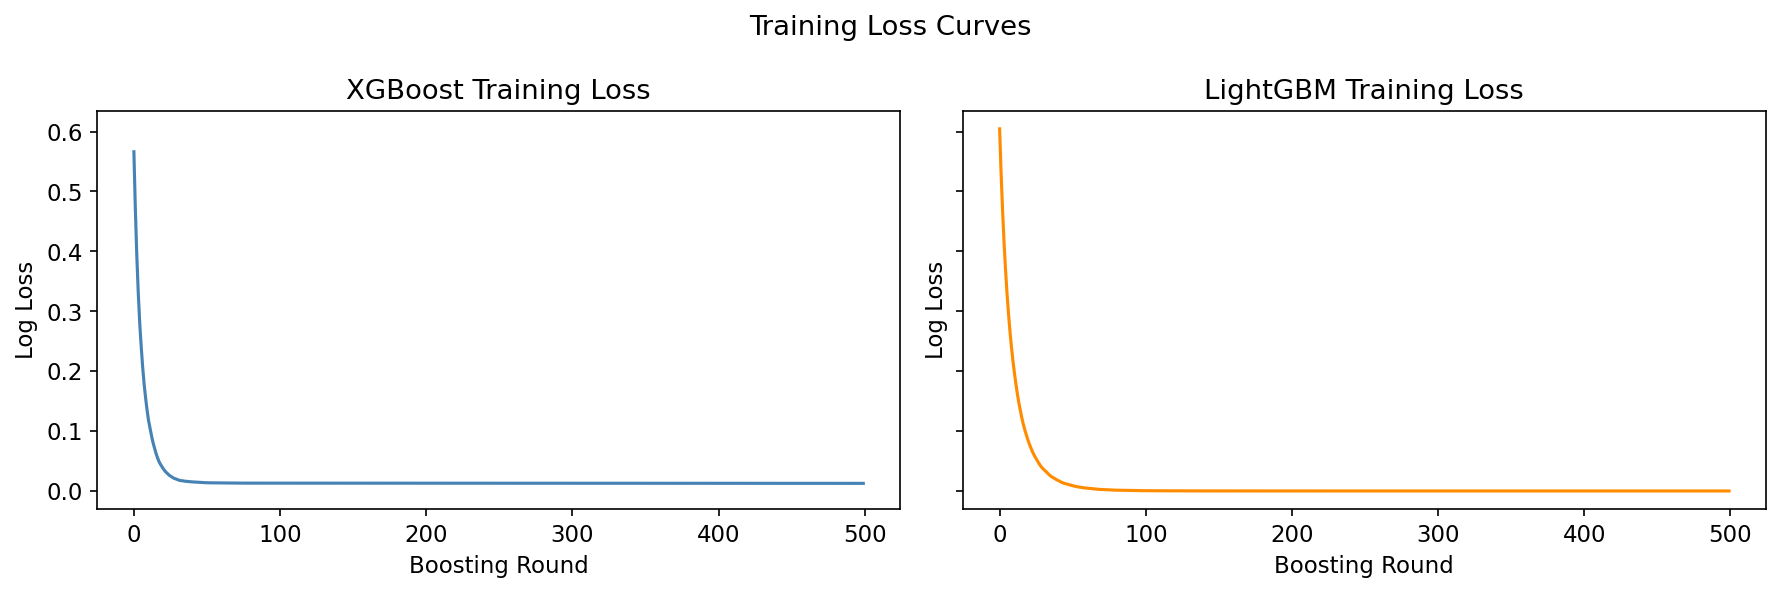

Saved training_loss_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, json_path, name, color in [
    (axes[0], f"{MODELS_DIR}/xgb_loss_curve.json",  "XGBoost",  "steelblue"),
    (axes[1], f"{MODELS_DIR}/lgbm_loss_curve.json", "LightGBM", "darkorange"),
]:
    with open(json_path) as f:
        curve = json.load(f)["logloss"]
    ax.plot(curve, color=color)
    ax.set_title(f"{name} Training Loss")
    ax.set_xlabel("Boosting Round")
    ax.set_ylabel("Log Loss")
plt.suptitle("Training Loss Curves")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/training_loss_curves.png", bbox_inches="tight")
plt.show()
print("Saved training_loss_curves.png")